<a href="https://colab.research.google.com/github/Susmithaputti0914/Accident-Data-Analysis-and-User-Management-System/blob/main/Copy_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

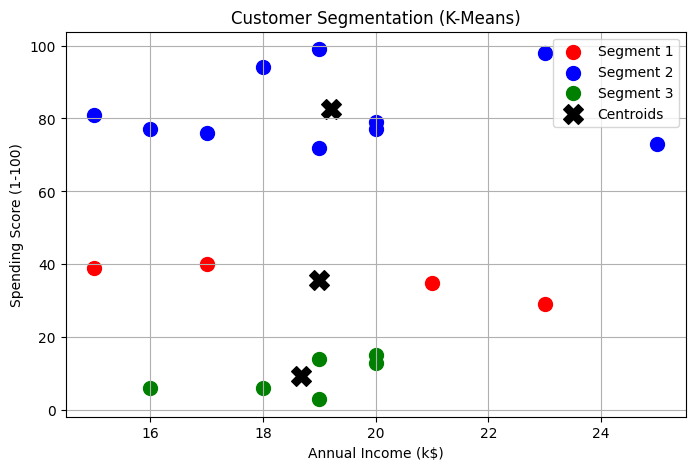

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load the dataset
csv_data = """CustomerID,Age,Annual_Income_k,Spending_Score,Marital_Status
1,19,15,39,Single
2,21,15,81,Single
3,20,16,6,Married
4,23,16,77,Single
5,31,17,40,Married
6,22,17,76,Single
7,35,18,6,Married
8,23,18,94,Single
9,64,19,3,Married
10,30,19,72,Single
11,67,19,14,Married
12,35,19,99,Single
13,58,20,15,Married
14,24,20,77,Single
15,37,20,13,Married
16,22,20,79,Single
17,35,21,35,Married
18,52,23,29,Married
19,35,23,98,Single
20,30,25,73,Single"""

df = pd.read_csv(io.StringIO(csv_data))

# 2. Select features for clustering (Income and Spending Score)
X = df[['Annual_Income_k', 'Spending_Score']]

# 3. Apply K-Means Clustering (Grouping into 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# 4. Plot the Customer Segments
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income_k'], cluster_data['Spending_Score'],
                c=colors[i], label=f'Segment {i+1}', s=100)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.title('Customer Segmentation (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()